In [1]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

from network import Net, NetDiscovery
from diff_equations import grad, cooling_law
from sklearn.model_selection import train_test_split

sns.set_theme()
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')

if torch.cuda.is_available():
    torch.empty(1).to(DEVICE)

print(f"PyTorch will use: {DEVICE}")

PyTorch will use: cpu


# Parameters

In [2]:
number_of_points = 100
noise_coeff = 1

pinn_collocation_points = 1000
parameter_discovery_collocation_points = 1000

pinn_loss2_weight = 1
parameter_discovery_loss_2_weight = 1

pinn_epochs = 30000
parameter_discovery_epochs = 40000

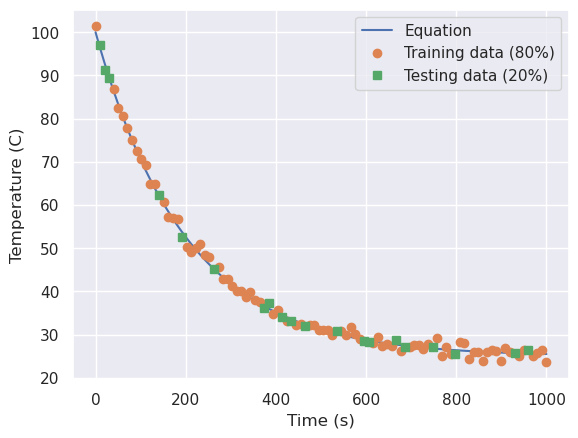

In [3]:
np.random.seed(10)

Tenv = 25
T0 = 100
R = 0.005


times = np.linspace(0, 1000, 1000)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, 1000, number_of_points)
T = eq(t) + noise_coeff * np.random.randn(number_of_points)

t_train, t_test, T_train, T_test = train_test_split(t, T, test_size=0.2, random_state=10)

plt.plot(times, temps)
plt.plot(t_train, T_train, 'o') 
plt.plot(t_test, T_test, 's')   
plt.legend(['Equation', 'Training data (80%)', 'Testing data (20%)'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.show()

# PINN

In [4]:
def physics_loss(model: torch.nn.Module, n_points=pinn_collocation_points):
    ts = torch.linspace(0, 1000, steps=n_points).view(-1,1).requires_grad_(True).to(DEVICE)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = R*(Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/30000, loss: 2214.73
Epoch 3000/30000, loss: 997.80
Epoch 6000/30000, loss: 191.79
Epoch 9000/30000, loss: 25.71
Epoch 12000/30000, loss: 2.68
Epoch 15000/30000, loss: 1.15
Epoch 18000/30000, loss: 1.01
Epoch 21000/30000, loss: 0.93
Epoch 24000/30000, loss: 1.01
Epoch 27000/30000, loss: 0.91


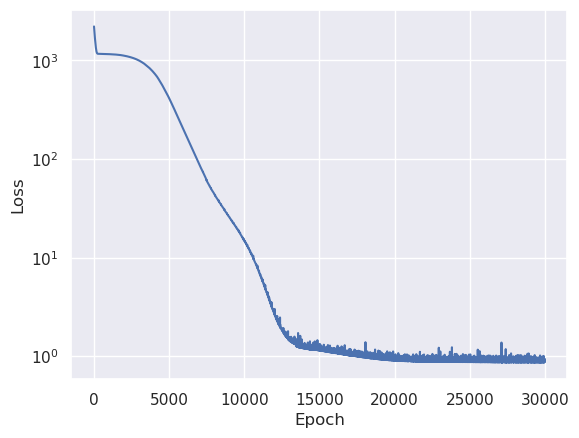

In [5]:
net = Net(1, 1, loss2=physics_loss, epochs=pinn_epochs, loss2_weight=pinn_loss2_weight, lr=1e-5).to(DEVICE)

losses = net.fit(t_train, T_train)

plt.plot(losses)
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Text(0.5, 0, 'Time (s)')

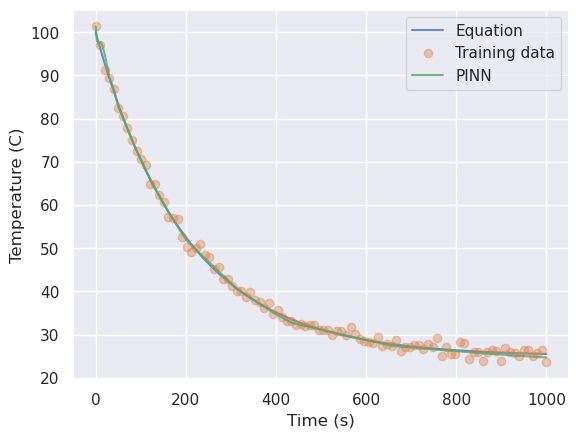

In [6]:
preds = net.predict(times)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o',alpha=0.4)
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

Mean Squared Error: 1.1462


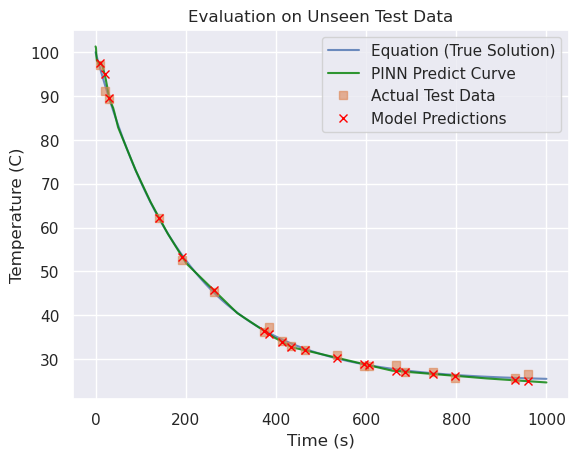

In [15]:
# Predict specifically for the test points to calculate MSE
T_pred = net.predict(t_test)
test_mse = np.mean((T_pred.flatten() - T_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

# Predict across the entire continuous time domain
continuous_preds = net.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds, label='PINN Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(t_test, T_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(t_test, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Evaluation on Unseen Test Data')
plt.show()

# Parameter discovery

In [8]:
def physics_loss_discovery(model: torch.nn.Module, n_points=parameter_discovery_collocation_points):

    ts = torch.linspace(0, 1000, steps=n_points).view(-1,1).requires_grad_(True).to(DEVICE)

    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = model.r * (Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/40000, loss: 2019.84
Epoch 4000/40000, loss: 1136.88
Epoch 8000/40000, loss: 660.51
Epoch 12000/40000, loss: 77.55
Epoch 16000/40000, loss: 2.84
Epoch 20000/40000, loss: 1.25
Epoch 24000/40000, loss: 1.01
Epoch 28000/40000, loss: 0.96
Epoch 32000/40000, loss: 0.90
Epoch 36000/40000, loss: 0.88


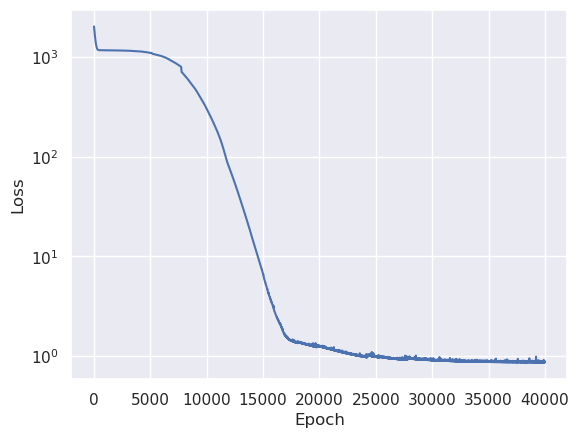

In [9]:
netdisc = NetDiscovery(1, 1, loss2=physics_loss_discovery, loss2_weight=parameter_discovery_loss_2_weight, epochs=parameter_discovery_epochs, lr=5e-6).to(DEVICE)

losses = netdisc.fit(t_train, T_train)

plt.plot(losses)
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Parameter containing:
tensor([0.0047], requires_grad=True)


Text(0.5, 0, 'Time (s)')

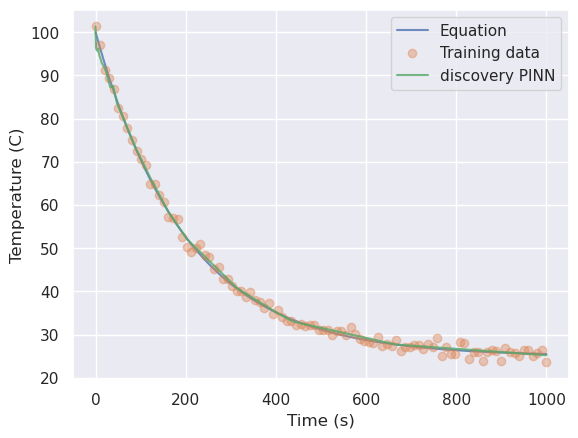

In [10]:
preds = netdisc.predict(times)
print(netdisc.r)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o', alpha=0.4)
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'discovery PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

Mean Squared Error: 0.9163
Discovered Cooling Rate (R): 0.004689
True Cooling Rate (R): 0.005


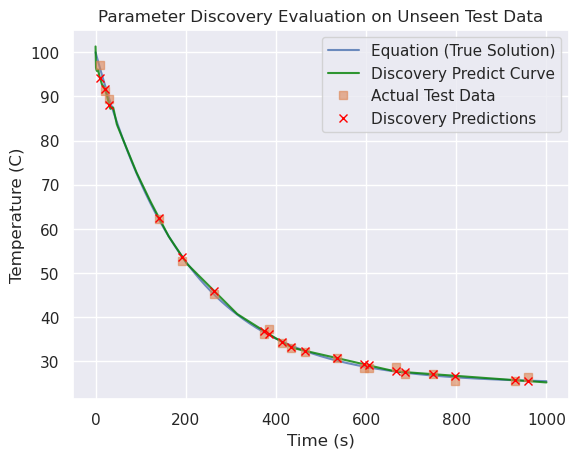

In [20]:
# Predict specifically for the test points to calculate MSE
T_pred_disc = netdisc.predict(t_test)

test_mse_disc = np.mean((T_pred_disc.flatten() - T_test)**2)
discovered_r = netdisc.r.item()
true_r = 0.005

print(f"Mean Squared Error: {test_mse_disc:.4f}")
print(f"Discovered Cooling Rate (R): {discovered_r:.6f}")
print(f"True Cooling Rate (R): {true_r}")

# Predict across the entire continuous time domain
continuous_preds_disc = netdisc.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds_disc, label='Discovery Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(t_test, T_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(t_test, T_pred_disc, 'x', label='Discovery Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Parameter Discovery Evaluation on Unseen Test Data')
plt.show()